# Notebook 2 — Data Enhancement

Demonstrates and validates the preprocessing + augmentation pipeline:
deskew → denoise → binarize → morphology, plus augmentation preview
and line-segmentation quality analysis.


## 1. Setup


In [ ]:
%matplotlib inline
import os, sys, random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T

sys.path.insert(0, os.path.abspath('..'))
ROOT = os.path.abspath('..')
IMAGES_DIR = os.path.join(ROOT, 'data', 'raw', 'images')

try:
    from src.preprocess import preprocess_image, segment_lines, deskew
    print('Loaded preprocessing functions from src.preprocess')
except Exception as e:
    print(f'[WARN] Could not import from src.preprocess: {e}')
    # ---- inline fallbacks ----
    def deskew(pil_img):
        arr = np.array(pil_img.convert('L'))
        edges = cv2.Canny(arr, 50, 200, apertureSize=3)
        lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength=50, maxLineGap=10)
        if lines is None:
            return pil_img
        angles = [np.degrees(np.arctan2(y2 - y1, x2 - x1)) for x1, y1, x2, y2 in lines[:, 0]]
        median = np.median(angles)
        if abs(median) < 0.5:
            return pil_img
        h, w = arr.shape
        M = cv2.getRotationMatrix2D((w // 2, h // 2), median, 1.0)
        rotated = cv2.warpAffine(np.array(pil_img.convert('RGB')), M, (w, h),
                                 borderMode=cv2.BORDER_REPLICATE)
        return Image.fromarray(rotated)

    def preprocess_image(pil_img):
        rgb = np.array(pil_img.convert('RGB'))
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        deskewed = np.array(deskew(pil_img).convert('RGB'))
        gray_d = cv2.cvtColor(deskewed, cv2.COLOR_RGB2GRAY)
        denoised = cv2.fastNlMeansDenoising(gray_d, None, 14, 7, 21)
        thresh = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 31, 10)
        kernel = np.ones((2, 2), np.uint8)
        opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        return Image.fromarray(cv2.cvtColor(
            cv2.merge([opened, opened, opened]), cv2.COLOR_BGR2RGB))

    def segment_lines(pil_img, min_height=15):
        gray = np.array(pil_img.convert('L'))
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        h_proj = np.sum(binary, axis=1)
        lines, in_line, start = [], False, 0
        for y, val in enumerate(h_proj):
            if val > 0 and not in_line:
                in_line, start = True, y
            elif val == 0 and in_line:
                if y - start >= min_height:
                    lines.append(pil_img.crop((0, start, pil_img.width, y)))
                in_line = False
        if in_line and pil_img.height - start >= min_height:
            lines.append(pil_img.crop((0, start, pil_img.width, pil_img.height)))
        return lines if lines else [pil_img]

random.seed(42)
print(f'Images dir: {IMAGES_DIR}')


ModuleNotFoundError: No module named 'cv2'

## 2. Load Sample Batch


In [ ]:
all_images = sorted(f for f in os.listdir(IMAGES_DIR) if f.lower().endswith('.png'))
sample_names = random.sample(all_images, min(8, len(all_images)))
sample_paths = [os.path.join(IMAGES_DIR, s) for s in sample_names]
print(f'Total images: {len(all_images)}, sampled: {len(sample_paths)}')


Total images: 1000, sampled: 8


## 3. Step-by-Step Preprocessing (Single Image)

Shows every stage of the pipeline side-by-side so we can debug
thresholding, denoising, and morphology parameters.


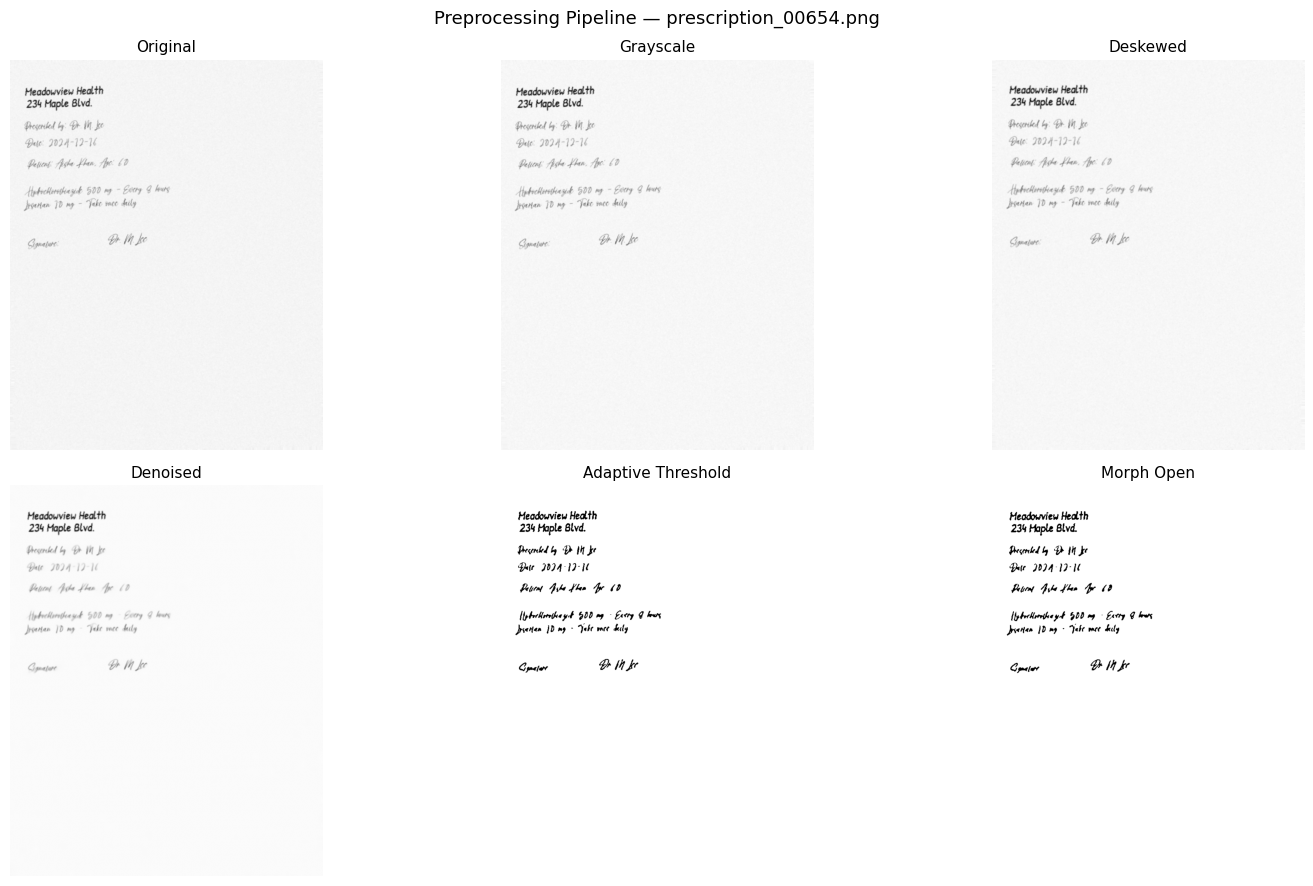

In [ ]:
one_path = sample_paths[0]
rgb_pil = Image.open(one_path).convert('RGB')
rgb = np.array(rgb_pil)
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

deskewed_pil = deskew(rgb_pil)
deskewed_gray = cv2.cvtColor(np.array(deskewed_pil.convert('RGB')), cv2.COLOR_RGB2GRAY)

denoised = cv2.fastNlMeansDenoising(deskewed_gray, None, 14, 7, 21)
thresholded = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 31, 10)
kernel = np.ones((2, 2), np.uint8)
opened = cv2.morphologyEx(thresholded, cv2.MORPH_OPEN, kernel)

stages = [
    ('Original', rgb),
    ('Grayscale', gray),
    ('Deskewed', deskewed_gray),
    ('Denoised', denoised),
    ('Adaptive Threshold', thresholded),
    ('Morph Open', opened),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (title, img) in zip(axes.flatten(), stages):
    cmap = 'gray' if img.ndim == 2 else None
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle(f'Preprocessing Pipeline — {os.path.basename(one_path)}', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Pixel Intensity Histograms (Before vs After)

Quantitative check: preprocessing should sharpen the bimodal distribution
(background vs ink), making OCR easier.


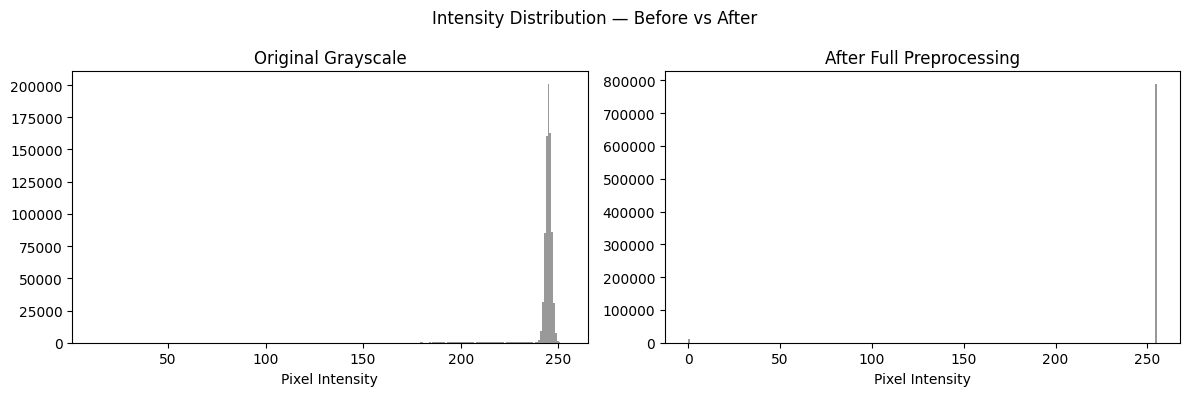

Dark-pixel ratio: 0.003 (before) → 0.015 (after)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(gray.ravel(), bins=256, color='gray', alpha=0.8)
axes[0].set_title('Original Grayscale')
axes[0].set_xlabel('Pixel Intensity')

axes[1].hist(opened.ravel(), bins=256, color='gray', alpha=0.8)
axes[1].set_title('After Full Preprocessing')
axes[1].set_xlabel('Pixel Intensity')

plt.suptitle('Intensity Distribution — Before vs After', fontsize=12)
plt.tight_layout()
plt.show()

ink_ratio_before = np.mean(gray < 128)
ink_ratio_after = np.mean(opened < 128)
print(f'Dark-pixel ratio: {ink_ratio_before:.3f} (before) → {ink_ratio_after:.3f} (after)')


## 5. Before / After Grid (6 Images)


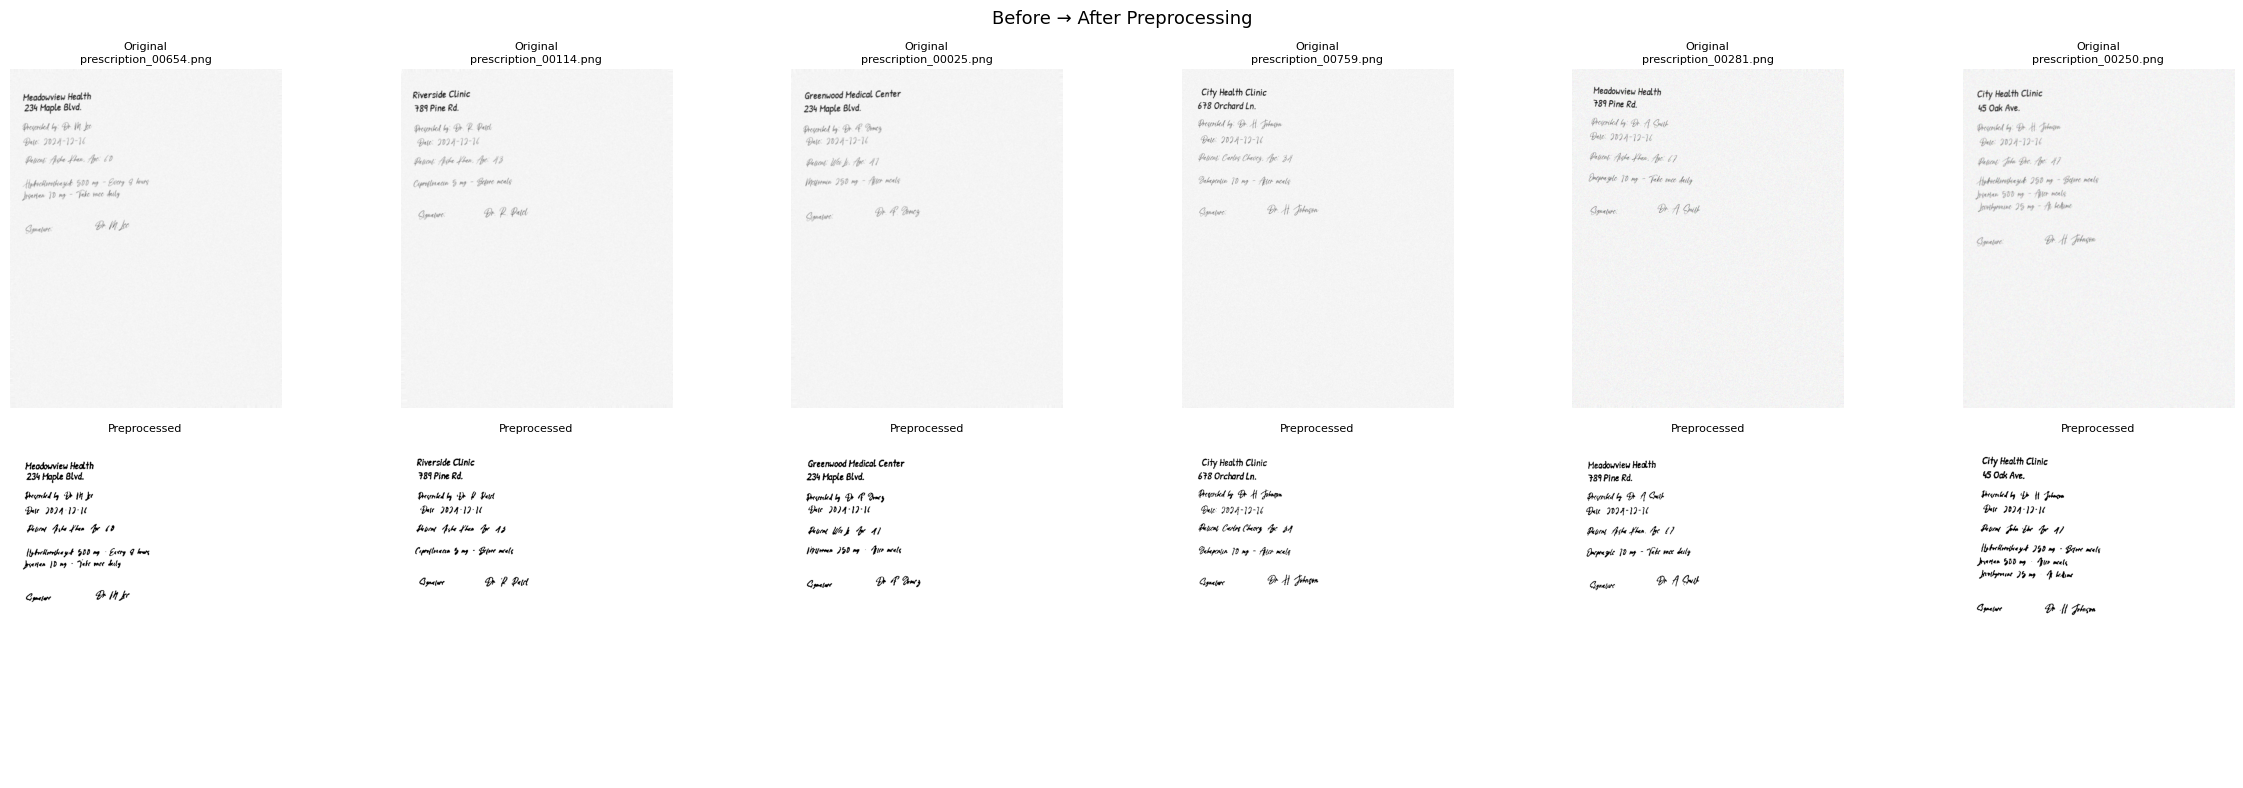

In [ ]:
show_paths = sample_paths[:6]
fig, axes = plt.subplots(2, len(show_paths), figsize=(4 * len(show_paths), 8))

for col, path in enumerate(show_paths):
    original = Image.open(path).convert('RGB')
    enhanced = preprocess_image(original)
    axes[0, col].imshow(np.array(original))
    axes[0, col].set_title(f'Original\n{os.path.basename(path)}', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(np.array(enhanced))
    axes[1, col].set_title('Preprocessed', fontsize=8)
    axes[1, col].axis('off')

plt.suptitle('Before → After Preprocessing', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Augmentation Preview


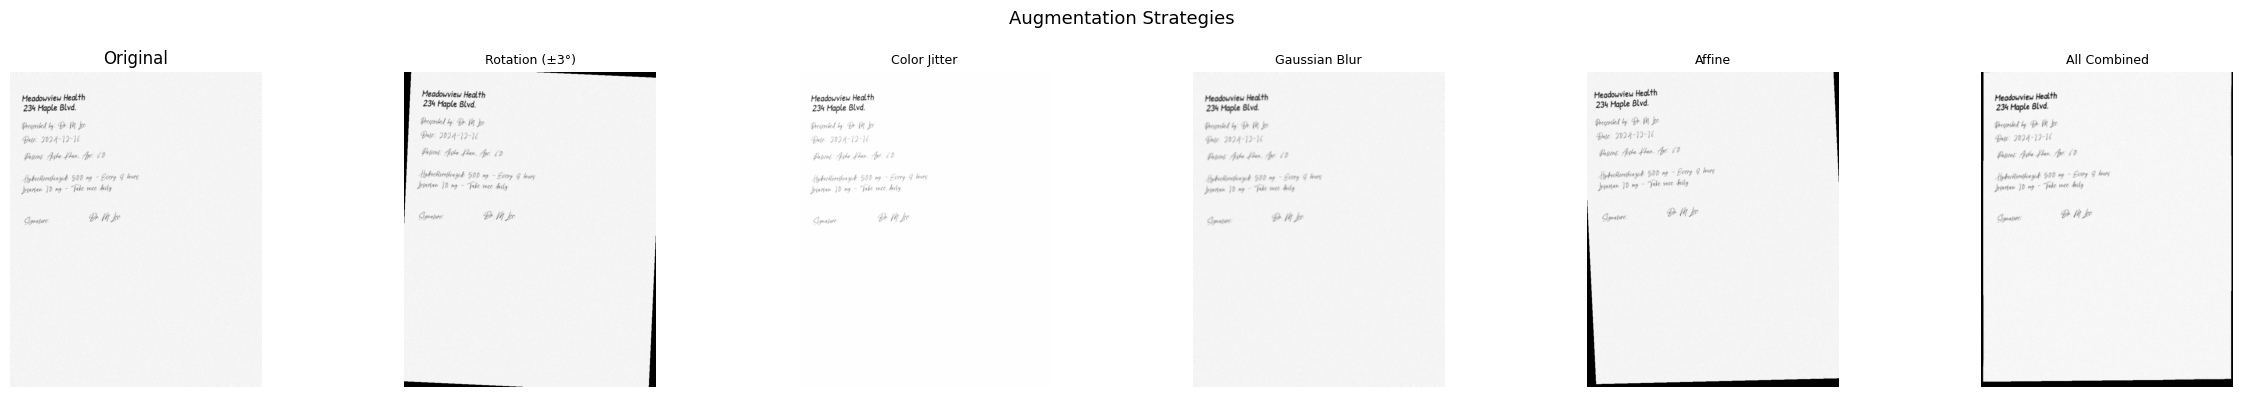

In [ ]:
base_img = Image.open(sample_paths[0]).convert('RGB')

augmentations = {
    'Rotation (±3°)': T.RandomRotation(degrees=3),
    'Color Jitter': T.ColorJitter(brightness=0.2, contrast=0.2),
    'Gaussian Blur': T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
    'Affine': T.RandomAffine(degrees=3, translate=(0.02, 0.02),
                              scale=(0.98, 1.02), shear=2),
    'All Combined': T.Compose([
        T.RandomRotation(degrees=3),
        T.ColorJitter(brightness=0.2, contrast=0.2),
        T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
        T.RandomAffine(degrees=3, translate=(0.02, 0.02),
                        scale=(0.98, 1.02), shear=2),
    ]),
}

fig, axes = plt.subplots(1, 1 + len(augmentations), figsize=(4 * (1 + len(augmentations)), 4))
axes[0].imshow(np.array(base_img))
axes[0].set_title('Original')
axes[0].axis('off')

for i, (name, tfm) in enumerate(augmentations.items(), 1):
    axes[i].imshow(np.array(tfm(base_img)))
    axes[i].set_title(name, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Augmentation Strategies', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Line Segmentation Analysis

Test line segmentation on several images and track how many lines are detected
per image — helps tune `min_height` and catch failure modes.


Segmenting lines: 100%|██████████| 8/8 [00:00<00:00, 38.52it/s]


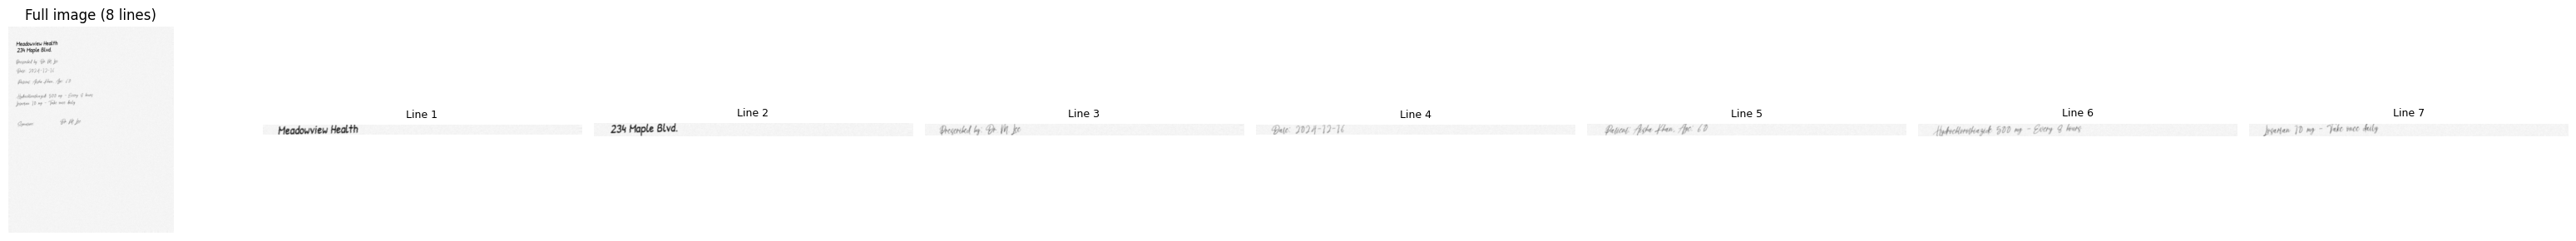

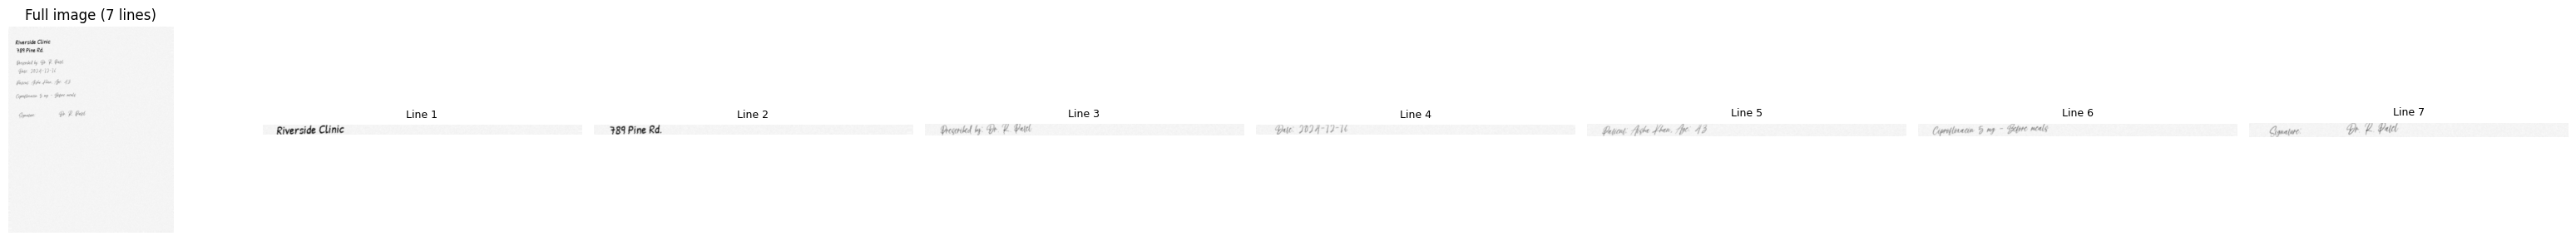

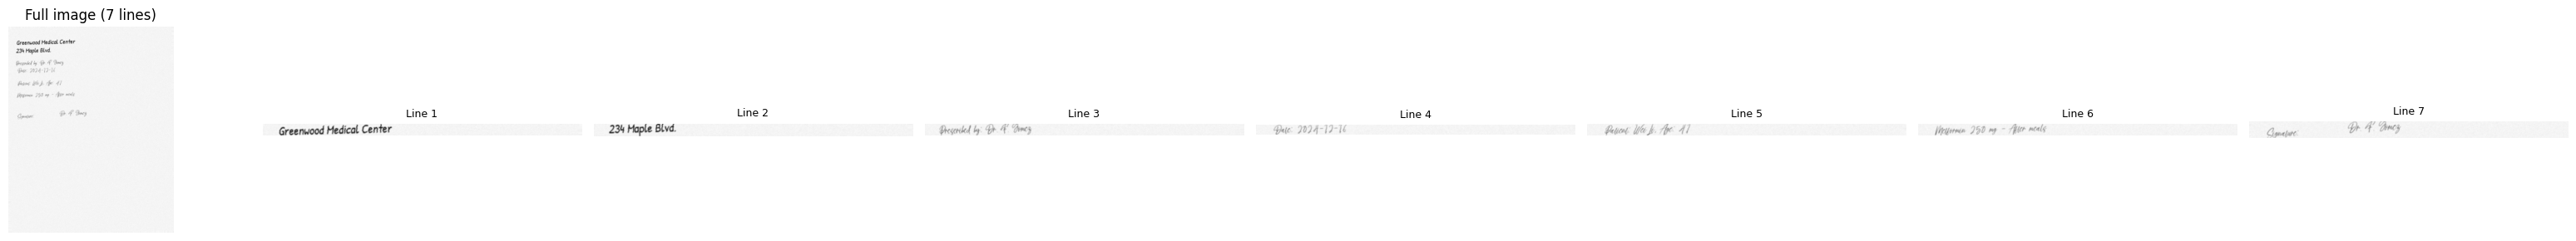

Lines per image — min: 7, max: 9, mean: 7.8


In [ ]:
line_counts = []
for p in tqdm(sample_paths, desc='Segmenting lines'):
    pil_img = Image.open(p).convert('RGB')
    lines = segment_lines(pil_img)
    line_counts.append(len(lines))

# Show detailed view for first 3
for p in sample_paths[:3]:
    pil_img = Image.open(p).convert('RGB')
    lines = segment_lines(pil_img)
    n = 1 + len(lines)
    fig, axes = plt.subplots(1, min(n, 8), figsize=(4 * min(n, 8), 3))
    if min(n, 8) == 1:
        axes = [axes]
    axes[0].imshow(np.array(pil_img))
    axes[0].set_title(f'Full image ({len(lines)} lines)')
    axes[0].axis('off')
    for j, line_crop in enumerate(lines[:7]):
        axes[j + 1].imshow(np.array(line_crop))
        axes[j + 1].set_title(f'Line {j + 1}', fontsize=9)
        axes[j + 1].axis('off')
    plt.tight_layout()
    plt.show()

print(f'Lines per image — min: {min(line_counts)}, max: {max(line_counts)}, '
      f'mean: {np.mean(line_counts):.1f}')


## 8. Full-Dataset Preprocessing Quality Check


In [ ]:
PROCESSED_DIR = os.path.join(ROOT, 'data', 'processed', 'images')
os.makedirs(PROCESSED_DIR, exist_ok=True)

success, fail, failed_files = 0, 0, []
for fname in tqdm(all_images, desc='Preprocessing full dataset'):
    try:
        img = Image.open(os.path.join(IMAGES_DIR, fname)).convert('RGB')
        processed = preprocess_image(img)
        processed.save(os.path.join(PROCESSED_DIR, fname))
        success += 1
    except Exception as e:
        fail += 1
        failed_files.append((fname, str(e)))

print(f'Success: {success}/{len(all_images)} (saved to {PROCESSED_DIR})')
print(f'Failures: {fail}')
if failed_files:
    for name, err in failed_files[:5]:
        print(f'  {name}: {err}')


Preprocessing full dataset: 100%|██████████| 1000/1000 [05:20<00:00,  3.12it/s]

Success: 1000/1000 (saved to /home/lokmane/Desktop/Medical_Prescription_OCR/data/processed/images)
Failures: 0


## 9. Save Augmented Images

Apply the combined augmentation pipeline to every preprocessed image and
write the results to `data/processed/augmented/`.


In [ ]:
AUGMENTED_DIR = os.path.join(ROOT, 'data', 'processed', 'augmented')
os.makedirs(AUGMENTED_DIR, exist_ok=True)

N_AUGMENTS_PER_IMAGE = 2

augment = T.Compose([
    T.RandomRotation(degrees=3),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
    T.RandomAffine(degrees=3, translate=(0.02, 0.02),
                   scale=(0.98, 1.02), shear=2),
])

aug_success, aug_fail = 0, 0
for fname in tqdm(all_images, desc='Augmenting dataset'):
    try:
        img = Image.open(os.path.join(PROCESSED_DIR, fname)).convert('RGB')
        stem, ext = os.path.splitext(fname)
        for i in range(N_AUGMENTS_PER_IMAGE):
            augment(img).save(os.path.join(AUGMENTED_DIR, f'{stem}_aug{i}{ext}'))
            aug_success += 1
    except Exception as e:
        aug_fail += 1

print(f'Augmented images saved: {aug_success} (to {AUGMENTED_DIR})')
print(f'Failures: {aug_fail}')


Augmenting dataset: 100%|██████████| 1000/1000 [02:58<00:00,  5.60it/s]

Augmented images saved: 2000 (to /home/lokmane/Desktop/Medical_Prescription_OCR/data/processed/augmented)
Failures: 0


## 10. Image → Annotation Mapping CSV

Build a CSV mapping every processed and augmented image to its
ground-truth annotation (read from `data/raw/annotations/<stem>.json`).
Augmented variants share the original image's annotation.


In [ ]:
import csv, json, re

ANNOTATIONS_DIR = os.path.join(ROOT, 'data', 'raw', 'annotations')
PROCESSED_ROOT = os.path.join(ROOT, 'data', 'processed')
MAPPING_CSV = os.path.join(PROCESSED_ROOT, 'image_annotations.csv')

def strip_ocr_tokens(text):
    return re.sub(r'\s+', ' ', text.replace('<s_ocr>', '').replace('</s>', '')).strip()

def load_ground_truth(stem):
    ann_path = os.path.join(ANNOTATIONS_DIR, stem + '.json')
    if not os.path.isfile(ann_path):
        return ann_path, '', ''
    with open(ann_path, encoding='utf-8') as f:
        ann = json.load(f)
    raw = ann.get('ground_truth', ann.get('text', ''))
    return ann_path, raw, strip_ocr_tokens(raw)

rows, missing = [], 0

for fname in sorted(os.listdir(PROCESSED_DIR)):
    if not fname.lower().endswith('.png'):
        continue
    stem = os.path.splitext(fname)[0]
    ann_path, raw, clean = load_ground_truth(stem)
    if not raw:
        missing += 1
    rows.append({
        'image_path': os.path.relpath(os.path.join(PROCESSED_DIR, fname), ROOT),
        'source': 'processed',
        'origin_id': stem,
        'annotation_path': os.path.relpath(ann_path, ROOT),
        'ground_truth_raw': raw,
        'ground_truth_clean': clean,
    })

for fname in sorted(os.listdir(AUGMENTED_DIR)):
    if not fname.lower().endswith('.png'):
        continue
    stem = os.path.splitext(fname)[0]
    origin = re.sub(r'_aug\d+$', '', stem)
    ann_path, raw, clean = load_ground_truth(origin)
    if not raw:
        missing += 1
    rows.append({
        'image_path': os.path.relpath(os.path.join(AUGMENTED_DIR, fname), ROOT),
        'source': 'augmented',
        'origin_id': origin,
        'annotation_path': os.path.relpath(ann_path, ROOT),
        'ground_truth_raw': raw,
        'ground_truth_clean': clean,
    })

with open(MAPPING_CSV, 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print(f'Wrote {len(rows)} rows to {MAPPING_CSV}')
print(f'Missing annotations: {missing}')


Wrote 3000 rows to /home/lokmane/Desktop/Medical_Prescription_OCR/data/processed/image_annotations.csv
Missing annotations: 0
